In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [2]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


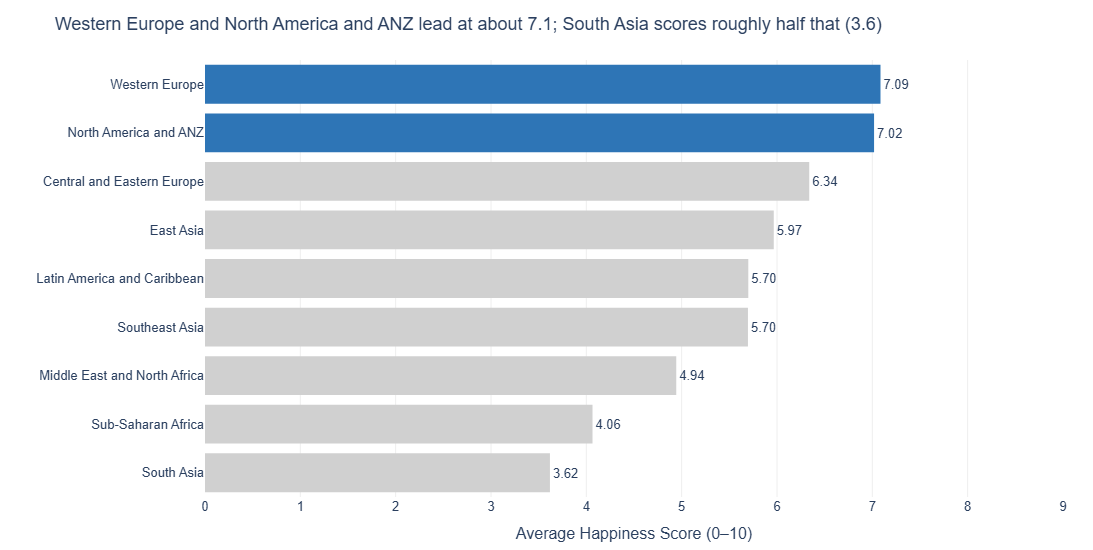

In [3]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # sort for horizontal bar

print(region_avg)

# Step 2: Build your chart

# Facts for the title, pulled from the data
best   = region_avg.iloc[-1]      # highest
second = region_avg.iloc[-2]      # second highest
worst  = region_avg.iloc[0]       # lowest

# Colour the top 2 regions blue, everything else grey
top2 = region_avg['Region'].iloc[-2:]
region_avg['highlight'] = np.where(region_avg['Region'].isin(top2), 'Top', 'Other')

fig = px.bar(
    region_avg,
    x='Happiness_Score', y='Region',
    orientation='h',
    color='highlight',
    color_discrete_map={'Top': '#2E75B6', 'Other': '#D0D0D0'},
    text='Happiness_Score',
    title=(f"{best['Region']} and {second['Region']} lead at about "
           f"{best['Happiness_Score']:.1f}; {worst['Region']} scores "
           f"roughly half that ({worst['Happiness_Score']:.1f})"),
    labels={'Happiness_Score': 'Average Happiness Score (0–10)', 'Region': ''},
    height=550
)

fig.update_traces(texttemplate='%{x:.2f}', textposition='outside', marker_line_width=0)

fig.update_layout(
    xaxis=dict(range=[0, 9], gridcolor='#EEEEEE'),   # zero baseline
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    showlegend=False,
    margin=dict(l=10, r=30, t=60, b=40)
)
fig.show()

Global average: 5.81


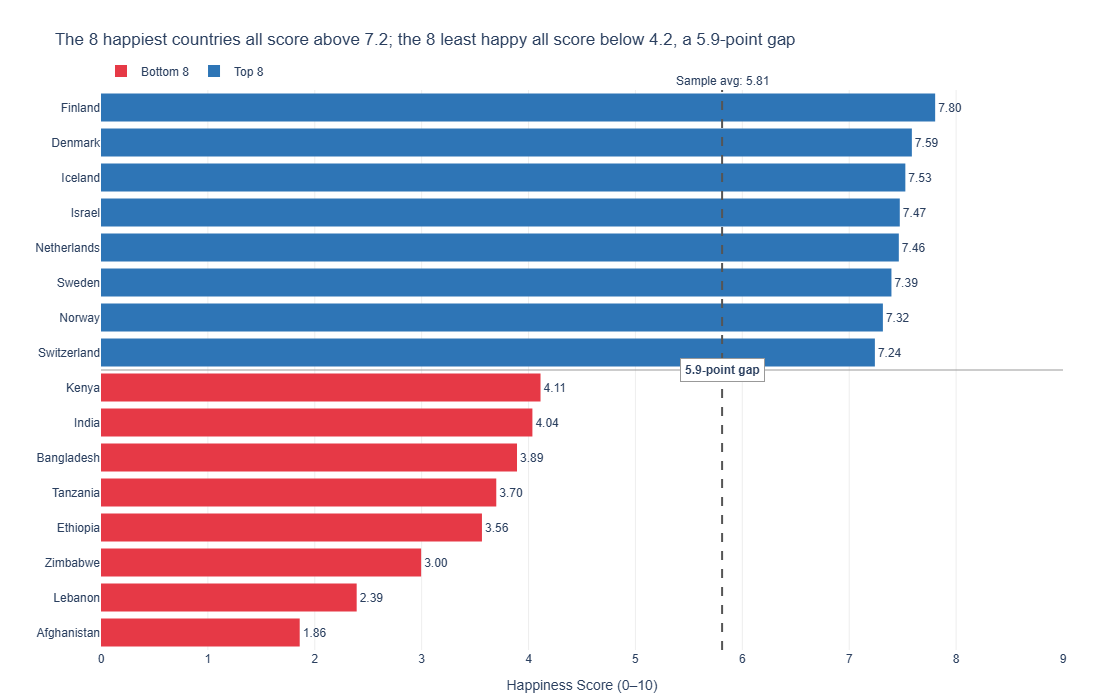

In [4]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

# Step 2: Build your chart

gap = top8['Happiness_Score'].max() - bottom8['Happiness_Score'].min()

fig = px.bar(
    combined,
    x='Happiness_Score', y='Country',
    orientation='h',
    color='Group',
    color_discrete_map={'Top 8': '#2E75B6', 'Bottom 8': '#E63946'},
    text='Happiness_Score',
    title=(f"The 8 happiest countries all score above 7.2; the 8 least happy "
           f"all score below 4.2, a {gap:.1f}-point gap"),
    labels={'Happiness_Score': 'Happiness Score (0–10)', 'Country': ''},
    height=700
)

fig.update_traces(texttemplate='%{x:.2f}', textposition='outside', marker_line_width=0)

# Stretch goal: global average reference line
fig.add_vline(x=global_avg, line_dash='dash', line_color='#555555',
              annotation_text=f'Sample avg: {global_avg:.2f}',
              annotation_position='top')

# Visual separator between the two groups (bars are positions 0–15; the gap is at 7.5)
fig.add_hline(y=7.5, line_color='#999999', line_width=1)

# Annotation that emphasises the gap
fig.add_annotation(
    x=global_avg, y=7.5, xref='x', yref='y',
    text=f'<b>{gap:.1f}-point gap</b>',
    showarrow=False, bgcolor='white',
    bordercolor='#999999', borderwidth=1, borderpad=4
)

fig.update_layout(
    xaxis=dict(range=[0, 9], gridcolor='#EEEEEE'),   # zero baseline
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    legend=dict(title='', orientation='h', y=1.06),
    margin=dict(l=10, r=30, t=90, b=40)
)
fig.show()

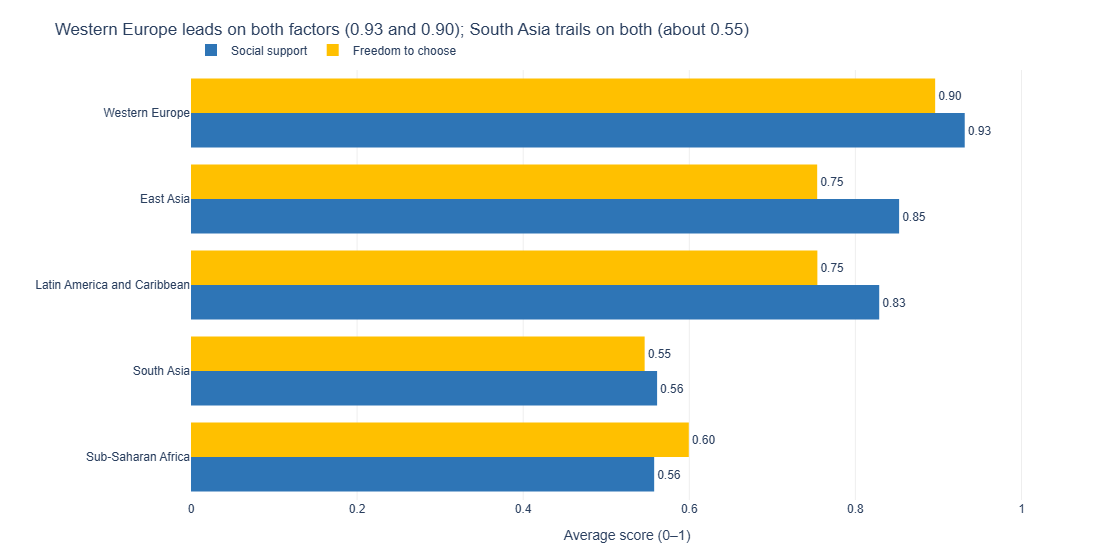

In [5]:
regions = ['Western Europe', 'Latin America and Caribbean', 'East Asia',
           'Sub-Saharan Africa', 'South Asia']

sub = df[df['Region'].isin(regions)]
grp = sub.groupby('Region')[['Social_Support', 'Freedom']].mean().reset_index()
grp = grp.sort_values('Social_Support')

# "Long" format: one row per region and factor, which px needs for grouped bars
long = grp.melt(id_vars='Region', value_vars=['Social_Support', 'Freedom'],
                var_name='Factor', value_name='Average')
long['Factor'] = long['Factor'].replace({'Social_Support': 'Social support',
                                         'Freedom': 'Freedom to choose'})

fig = px.bar(
    long, y='Region', x='Average', color='Factor',
    orientation='h', barmode='group',
    color_discrete_map={'Social support': '#2E75B6', 'Freedom to choose': '#FFC000'},
    text='Average',
    title='Western Europe leads on both factors (0.93 and 0.90); South Asia trails on both (about 0.55)',
    labels={'Average': 'Average score (0–1)', 'Region': ''},
    height=550
)
fig.update_traces(texttemplate='%{x:.2f}', textposition='outside', marker_line_width=0)
fig.update_layout(
    xaxis=dict(range=[0, 1.05], gridcolor='#EEEEEE'),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    legend=dict(orientation='h', y=1.08, title=''),
    margin=dict(l=10, r=30, t=70, b=40)
)
fig.show()